## Studija slučaja evaluacije kreditnog rizika

U cilju ilustracije ilustracije praktične upotrebe algoritma k-najbližih suseda, biće prikazana njegova primena u Pajton okruženju 

Koristimo bazu *German Credit Dataset* koja je javno dostupna, i direktno je učitavamo iz UCI Machine Learning repozitorijuma koristeći funkciju `fetch_openml` putem biblioteke scikit-learn. Ovim pristupom proces učitavanja podataka je automatizovan, bez potrebe za ručnim preuzimanjem i lokalnim skladištenjem baze podataka. Posmatrana baza sadrzi 1000 instanci opisanih putem 20 numeričkih i kategorijskih atributa o karakteristikama klijenata i njihovim kreditnim zahtevima. Zbog svoje strukture ova baza se često koristi kao primer za primenu klasifikacionih algoritama. Ciljna promenljiva u ovom skupu podataka je binarna i klasifikuje klijente na "dobre" ili "loše" platiše na osnovu procenjenog kreditnog rizika, tj. procjenjuje se da li klijent pripada grupi niskog ili visokog kreditnog rizika.


Skup svih 20 ulaznih promenljivih (atributa) su opisane u nastavku:
```{table} Opis ulaznih promenljivih 
:label: point_spec
:align: center
:header-rows: 1

| #  | Originalni naziv | Opis na srpskom | Tip podatka| 
|----|-----------------|----------------|------------|
| 1  | Status of existing checking account | Status tekućeg računa klijenta | Kategorički |
| 2  | Duration in month | Trajanje kredita (u mesecima) | Numerički |
| 3  | Credit history | Kreditna istorija klijenta | Kategorički |
| 4  | Purpose | Svrha kredita | Kategorički |
| 5  | Credit amount | Iznos kredita | Numerički |
| 6  | Savings account/bonds | Status štednog računa ili obveznica | Kategorički |
| 7  | Present employment since | Dužina trenutnog zaposlenja | Kategorički |
| 8  | Installment rate in percentage of disposable income | Rata kredita kao procenat raspoloživog dohotka | Numerički |
| 9  | Personal status and sex | Lični status i pol | Kategorički |
| 10 | Other debtors / guarantors | Ostali dužnici ili jemci | Kategorički |
| 11 | Present residence since | Dužina boravka na trenutnoj adresi | Numerički |
| 12 | Property | Vrsta imovine | Kategorički |
| 13 | Age in years | Starost klijenta (u godinama) | Numerički |
| 14 | Other installment plans | Ostali kreditni aranžmani | Kategorički |
| 15 | Housing | Status stanovanja | Kategorički |
| 16 | Number of existing credits at this bank | Broj postojećih kredita u istoj banci | Numerički |
| 17 | Job | Zanimanje | Kategorički |
| 18 | Number of people being liable to provide maintenance for | Broj izdržavanih lica | Numerički |
| 19 | Telephone | Posedovanje telefona | Kategorički |
| 20 | Foreign worker | Status stranog radnika | Kategorički |
 ```

**Ciljna varijabla (klasifikacija rizika):**

- **1 (Nizak rizik):** klijent sa stabilnim kreditnim profilom i minimalnim stepenom rizika.  
- **2 (Visok rizik):** klijent sa povišenim stepenom rizika i potencijalnom nesolventnošću.


*Priprema radnog okruženja i učitavanje biblioteka* 

Pre same implementacije modela potrebno je učitati odgovarajuće softverske biblioteke. U nastavku se učitavaju sve biblioteke neophodne za rad, zajedno sa njihovim skraćenim nazivima, koji će se koristiti radi jednostavnijeg i preglednijeg pozivanja njihovih funkcija i atributa tokom implementacije. 


* **Pandas (`pd`)**: Primarna biblioteka za rad sa tabelarnim podacima (DataFrames). Koristi se za učitavanje podataka (na primer iz `.csv` datoteka), njihovo čišćenje i efikasnu manipulaciju tabelarnim strukturama. Skraćenica `pd` predstavlja standardnu konvenciju u Python zajednici.

* **NumPy (`np`)**: Osnovna biblioteka za efikasan rad sa višedimenzionalnim nizovima (arrays) i izvođenje brzih numeričkih i matematičkih operacija. Skraćenica `np` predstavlja standardnu konvenciju u Python zajednici. Iako se NumPy ponekad ne koristi direktno u kodu, biblioteka Pandas se u velikoj meri oslanja na njega u pozadini čineći rad sa nizovima i tabelarnim podacima znatno efikasnijim.

* **Scikit-learn (`sklearn`)**: Najznačajnija biblioteka za klasično mašinsko učenje, iz koje u ovom koraku koristimo:
    * `KNeighborsClassifier`: Algoritam za izgradnju modela k-najbližih suseda za klasifikaciju.
    * `train_test_split`: Alat za podelu podataka na podskupove za obuku i testiranje.
    * `metrics`: Funkcije za preciznu evaluaciju performansi (tačnost, preciznost, odziv) obučenog modela. Modul `sklearn.metrics` se učitava kako bi mogli da koristimo metrike pomoću kojeg radimo evaluaciju našeg modela. `classification_report` nam daje izveštaj koji sumira performansama klasifikacije, ne otkriva samo učestalost grešaka, već i kakve greške model pravi.
    * `fetch_openml`: Funkcija automatizuje proces preuzimanja podataka koristeći API poziv ka OpenML repozitorijumu umesto manuelnog preuzimanja fajlova. Funkcija `fetch_openml` pripada biblioteci `scikit-learn` u okviru modlua `sklearn.datasets`, i koristi se za automatizovano preuzimanje javno dostupnih skupova podataka sa repozitorijuma *OpenML* i njihovo direktno učitavanje u Python okruženje.
        - Podacima se pristupa putem naziva, jedinstvenog identifikacionog broja ili specifične specifične verzije skupa podataka.
        - Ova funkcija automatski učitava podatke u `Pandas DataFrame` (podrazumevano) ili `NumPy` nizove (podešavajem parametra `as_frame` na `False`). 
    * `StandardScaler`: Standardizuje numeričke podatke tako da imaju srednju vrednost 0 i standardnu devijaciju 1. 

In [15]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

*Definisanje imena kolona*

Radi bolje čitljivost koda, u ovoj fazi manuelno dodeljujemo deskriptivna imena svakom atributu.

In [16]:
columns = [
    "Status_racuna", "Trajanje_kredita", "Kreditna_istorija", "Svrha",
    "Iznos_kredita", "Stednja", "Radni_staz", "Stopa_rata",
    "Licni_status", "Drugi_duznici", "Vreme_stanovanja",
    "Imovina", "Starost", "Drugi_krediti",
    "Stanovanje", "Broj_kredita",
    "Zaposlenost", "Broj_izdrzavanih", "Telefon", "Strani_radnik",
    "Klasa"
]

*Učitavanje skupa podataka*

U ovom koraku definišemo internet adresu (engl. URL) koja vodi do **German Credit** skupa podataka. Ovaj dataset je deo čuvenog **UCI Machine Learning Repository** arhiva.

In [17]:
VebAdresa = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

Učitavamo skup podataka u Pandas DataFrame, pri čemu koristimo `sep=" "` da označimo da su vrednosti odvojene razmakom. Postavljanjem parametra `header=None`označavamo da dataset ne sadrži red sa imenima kolona, dok postavljanjem parametra `names=columns` dodeljujemo nazive kolona onako kako su u prethodnom redu definisani i smešteni u niz `columns`.

Ako se u zagradama ne navede broj, metoda `baza.head()` podrazumevano prikazuje prvih 5 redova skupa podataka.  
Ukoliko se u zagradama navede broj, prikazuju se prvih onoliko redova koliko je zadato. Analogno tome, metoda `baza.tail()` prikazuje poslednjih 5 redova ako broj nije preciziran, odnosno poslednjih onoliko redova koliko je navedeno u zagradama.



In [18]:
baza = pd.read_csv(VebAdresa, sep=" ", header=None, names=columns)
baza.head()

,Status_racuna,Trajanje_kredita,Kreditna_istorija,Svrha,Iznos_kredita,Stednja,Radni_staz,Stopa_rata,Licni_status,Drugi_duznici,...,Imovina,Starost,Drugi_krediti,Stanovanje,Broj_kredita,Zaposlenost,Broj_izdrzavanih,Telefon,Strani_radnik,Klasa
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka:

- **count**: Broj ne-nedostajućih vrednosti u koloni.  
- **mean**: Srednja vrednost (prosek) kolone.  
- **std**: Standardna devijacija (koliko se vrednosti prosečno udaljavaju od srednje vrednosti).  
- **min**: Najmanja vrednost u koloni.  
- **25%**: Donji kvartil (prva četvrtina podataka).  
- **50%**: Medijana (srednja vrednost).  
- **75%**: Gornji kvartil (treća četvrtina podataka).  
- **max**: Najveća vrednost u koloni.  

> Napomena: Standardna metoda `describe()` analizira isključivo **numeričke kolone**. Kako biste dobili uvid i u **kategoričke podatke**, koristite argument `include='all'`, što dodatno vraća:
> - **unique** – broj jedinstvenih vrednosti u koloni
> - **top** – najčešća vrednost (moda)
> - **freq** – frekfencija ponavljanja najčešće vrednosti 

In [19]:
baza.describe()

,Trajanje_kredita,Iznos_kredita,Stopa_rata,Vreme_stanovanja,Starost,Broj_kredita,Broj_izdrzavanih,Klasa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Pozovanje metode`.info()` jedan je od prvih koraka u analizi podataka. Njenim pozivanjem dobijamo izveštaj o strukturi posmatranog skupa podataka, uključujući tip objekta, opsega indeksa, broj redova, listu kolona, broj popunjenih vrednosti za svaki atribut (što nam omogućava odentifikaciju nedostajućih vrednosti), tip podataka svake kolone, količinu memorije koju zauzima skup podataka. 

> Metod `.info()` je koristan za brzu proveru nedostajućih vrednosti i tipova podataka u skupu podataka.


In [20]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
Status_racuna        1000 non-null object
Trajanje_kredita     1000 non-null int64
Kreditna_istorija    1000 non-null object
Svrha                1000 non-null object
Iznos_kredita        1000 non-null int64
Stednja              1000 non-null object
Radni_staz           1000 non-null object
Stopa_rata           1000 non-null int64
Licni_status         1000 non-null object
Drugi_duznici        1000 non-null object
Vreme_stanovanja     1000 non-null int64
Imovina              1000 non-null object
Starost              1000 non-null int64
Drugi_krediti        1000 non-null object
Stanovanje           1000 non-null object
Broj_kredita         1000 non-null int64
Zaposlenost          1000 non-null object
Broj_izdrzavanih     1000 non-null int64
Telefon              1000 non-null object
Strani_radnik        1000 non-null object
Klasa                1000 non-null int64
dtypes: int64(8), ob

*Binarizacija ciljne klase; Razdvajanje podataka na ulazne atribute i izlazne labele*


1. **Binarizacija ciljne klase**: U posmatranoj bazi ciljna promenljiva uzima vrednosti `1` (dobar kreditni rizik) i `2` (loš kreditni rizik). Koristeci metodu `.map()` izvršićemo prekodiranje ovih vrednosti `1` u `1` (dobar klijent), i `2` u `1` (rizičan klijent) radi usklađivanja sa standardima binarne klasifikacije.

2. **Razdvajanje na ulazne atribute i izlazne labele**:
    * **Matrica atributa (`X`)**: Izdvajanjem kolone "`"Klasa"` iz skupa podataka formiramo matricu atributa (nezavisnih promenljivih). Ovi podaci predstavljaju ulazne parametre ($X$) na osnovu kojih model uči da prepoznaje obrasce i donosi predviđanja. 
    * **Izlazna labela (`y`)**: Kolona `"Klasa"` se izdvaja kao **zavisna promenljiva**, odnosno ciljni vektor ($y$), čija se vrednost predviđa na osnovu ulaznih podataka. U kontekstu mašinskog učenja, ovaj vektor predstavlja "labelu" ili tačan odgovor na osnovu kojeg model uči da prepoznaje obrasce i vrši klasifikaciju novih primera.


In [21]:
# Transformacija izlazne labele u binarni oblik
baza["Klasa"] = baza["Klasa"].map({1: 1, 2: 0})

X = baza.drop("Klasa", axis=1)
y = baza["Klasa"]

Primenjujemo funkciju `pd.get_dummies` za transformaciju kategoričkih promenljivih u numerički format pogodan za modele mašinskog učenja.
 - *One-Hot Encoding*: Svaka različita kategorija iz originalne kolone dobija zasebnu indikator promenljivu, pri čemu vrednost 1 označava prisustvo određene kategorije, a 0 njeno odsustvo.
 - *Uklanjanje prve kategorije (`drop_first=True`)*: Ova opcija eliminiše jednu od novonastalih kolona za svaku originalnu varijablu kako bi se izbegla multikolinearnost.

In [22]:
# One-Hot Encoding kategorijskih promenljivih
X_encoded = pd.get_dummies(X, drop_first=True)

Bazu možemo učitati i koristeći funkciju `fetch_openml()`, učitali bismo bazu podataka 'German Credit' pozivanjem sledeće linije koda: 

data = fetch_openml(name="credit-g", version=1)


```{admonition} Razlika između nove i starije verzije 'scikit-learn'


:class: seealso
Napomena o argumentu `as_frame` u `fetch_openml()`

U novijim verzijama biblioteke **scikit-learn**, funkcija `fetch_openml()` podržava argument `as_frame=True`, koji omogućava da se podaci odmah učitaju u **Pandas DataFrame** i Series:

```python
data = fetch_openml(name="credit-g", version=1, as_frame=True)

X = baza.data
y = baza.target
```

*Podela na skup za treniranje i skup za testiranje. Standardizacija numeričkih atributa*

* Parametar `test_size=0.3` razdavaja skup podataka tako da će 30% podataka biti sačuvano za testiranje, dok će se 70% koristiti za obuku modela. 

* Parametar `random_state` se koristi kako bi svaki put kada iznova pokrenemo kod podela podataka na trening i test skup bila uvek ista, što takođe omogućava reproduktivnost. Ovakva fiksna podela je korisna jer osigurava  korišćenje istog skupa treniranje i istog skupa za testiranje, čime postižemo da su rezultati različitih verzija modela direktno uporedivi. Napomenimo da se umesto `42` može se koristiti bilo koji drugi broj, i naravno dobijammo drugačiju podelu podataka. U sekciji "Stabla odlučivanja" možete pročitati zanimljivost zašto se baš `random_state=42` često pojavljuje.

* Drugim rečima, `random_state` **fiksira generator slučajnih brojeva** koji se koristi za nasumičnu podelu skupa, pa su rezultati predvidljivi i ponovljivi.

* Korišćenjem parametra `stratify`, obezbeđujemo da distribucija klasa u skupu za testiranje održava identične proporcije klasa kakve postoje u izvornoj populaciji podataka.

* `StandardScaler` je alat iz biblioteke `scikit-learn` koji vrši skaliranje, tj. koji numeričke podatke transformiše tako da njihova srednja vrednost bude $0$, a standardna devijacija $1$. Kako koristi metrike rastojanja algoritam KNN je osetljiv na skalu ulaznih podataka, pa je neophodno izvršiti standardizaciju kako bi svi atributi imali ravnomeran doprinos u odlučivanju

* Nakon standardizacije, primenjuje se metoda `fit_transform` nad trenažnim podacima (`X_train`). Ovaj korak je dvostruk:  
    > **Fit faza:** Algoritam analizira skup za treniranje kako bi izračunao aritmetičku sredinu ($\mu$) i standardnu devijaciju ($\sigma$) za svaku karakteristiku; 
    
    > **Faza transformacije:** Koristeći ove parametre, vrši se matematička transformacija podataka tako da se svako obeležje svede na standardnu normalnu raspodelu.
    > Na skupu za testiranje primenjuje metodu `.transform()`primenjujući srednju vrednost i varijansu koje su naučena na skupu za treniranje. Ovde ne koristimo `fit` jer u realnim uslovima testni podaci su nepoznati.    
---

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Standardizacija numeričkih atributa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:645: DataConversionWarning: Data with input dtype uint8, int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:464: DataConversionWarning: Data with input dtype uint8, int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: DataConversionWarning: Data with input dtype uint8, int64 were all converted to float64 by StandardScaler.
  


*Inicijalizacija i obuka KNN modela*

Kreiramo instancu klase `KNeighborsClassifier` uz definisanje ključnih hiperparametara:

* **`n_neighbors=5`**: Određujemo da će model donositi odluku na osnovu 5 najbližih suseda. U ovom koraku ćemo eksperimentalno postaviti vrednost parametra $k=5$ kako bismo demonstrirali rad algoritma i analizirali njegove performanse na konkretnom primeru. Detaljnija analiza uticaja parametra $k$ na ponašanje modela, kao i metode za izbor njegove optimalne vrednosti, biće razmatrane u nastavku.

    * Biramo neparan broj kako bismo smanjili verovatnoću "nerešenog" ishoda pri glasanju između dve klase. 
    * **Šta se dešava ako je ipak nerešeno?** U situacijama sa više klasa (npr. rezultat glasanja je $2:2:1$), ili kada je broj suseda paran ($2:2$), `scikit-learn` biblioteka najčešće rešava problem na jedan od dva načina:
        1. **Težinsko glasanje:** Ako je podešen parametar `weights='distance'`, prednost dobija klasa čiji su susedi fizički bliži upitnoj tački.
        2. **Redosled klasa:** Ako su težine jednake (`uniform`), algoritam obično bira klasu koja se prva pojavljuje u redosledu (najčešće ona sa manjim indeksom ili koja je prva u labelama).
* **`metric="euclidean"`**: Koristimo **Euklidsku udaljenost** kao standardnu metriku za izračunavanje prostorne bliskosti između tačaka. S obzirom na to da smo prethodno skalirali podatke, ova metrika će dati stabilne i pouzdane rezultate.



*Treniranje modela (`.fit` metod)*
Pozivom metode `.fit(X_train_scaled, y_train)`, model se obučava na standardizovanom trenažnom skupu:

1.  **Mapiranje podataka:** Za razliku od algoritama koji uče složene matematičke funkcije, KNN je tzv. **"lenji učenik"** (*lazy learner*). On u ovoj fazi jednostavno skladišti (indeksira) trenažne primere i njihove labele (`y_train`) u memoriju.
2.  **Spremnost za predviđanje:** Nakon izvršavanja ove linije koda, klasifikator je spreman da na osnovu memorisanih podataka analizira nove, testne uzorke i dodeli im odgovarajuću klasu.

In [24]:
# Definisanje KNN klasifikatora 
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean") 
# Treniranje modela 
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='euclidean',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform')

Pre nego što ocenimo performanse modela, demonstriramo identifikaciju suseda i mehanizam identifikacije suseda i način na koji model, kroz proces glasanja, donosi konačnu odluku za konkretan test primer. 

Algoritam KNN, kao metoda lenjog učenja, ne gradi model unapred, već čeka trenutak predikcije kako bi uporedio novi podatak sa postojećima, a proces predikciju se zasniva na tri ključna koraka:

1. Izračunavanje rastojanja između test uzorka i svakog pojedinačnog primera iz trening skupa.
   
2. Pronalaženje $k$ najsrodnijih suseda na osnovu prethodno izračunatih distanci.
   
3. Finalna klasifikacija se vrši putem **većinskog glasanja**, gde klasa koja je najzastupljenija među susedima određuje pripadnost novog podatka.

> **Napomena:** Iako je k-NN izuzetno fleksibilan, njegova priroda nosi određene izazove pri radu sa velikim skupovima podataka:
    - Memorijska zahtevnost: Model mora da čuva čitav skup podataka u memoriji.
    - Računarska složenost: Pri svakoj novoj predikciji, algoritam mora da "pretraži" bazu i izračuna udaljenosti, što zahteva značajnu procesorsku snagu.

Za razliku od parametarskih modela, KNN ne formira eksplicitnu funkciju odlučivanja tokom treniranja, već odluku donosi u realnom vremenu. U nastavku ćemo praktično demonstrirati ovaj mehanizam identifikacije suseda i prikazati kako model, kroz proces poređenja i glasanja, donosi konačnu odluku za ovaj obrađen primer.

*Analiza mehanizma predikcije*

Pre nego što model donese konačnu odluku, mehanizam njegovog rada možemo istražiti pomoću metode `.kneighbors()`. Ovaj postupak se sastoji od sledećih koraka:

* `.reshape(1, -1)`: budući da `scikit-learn` očekuje dvodimenzionalni niz (matricu) kao ulaz, transformiše jedan test primer u oblik (1 red, n kolona).
    
* `.kneighbors()`: 
    Ovo je ključna funkcija koja nam omogućava transparentnost modela. Ona ne vraća klasu, već dva bitna niza podataka:
    1. `distances`: Numeričke vrednosti rastojanja između test primera i njegovih $k$ najbližih suseda.
    2. `indices`: Redne brojeve (indekse) tih suseda u originalnom trening skupu.

---

*Interpretacija rezultata*
Pomoću ovih podataka možemo precizno definisati:
1. *Lokalni kontekst:* Koji tačno uzorci iz baze znanja (trening skupa) direktno utiču na klasifikaciju našeg primera.
2. *Stepen sličnosti:* Koliko su ti susedi zapravo blizu (slični) posmatranom primeru, što nam pomaže da procenimo pouzdanost same predikcije.

In [25]:
# Biramo prvi primer iz test skupa
test_sample = X_test_scaled[0].reshape(1, -1)

# Pronalazimo 5 najbližih suseda
distances, indices = knn.kneighbors(test_sample)

print("Indeksi najbližih suseda:", indices)
print("Rastojanja do suseda:", distances)


Indeksi najbližih suseda: [[494 224 425 144 282]]
Rastojanja do suseda: [[4.92640798 4.97689824 5.18098496 5.21376189 5.64843548]]


*Kako model donosi odluku?*
U ovom koraku vršimo uvid u "glasačko telo" našeg algoritma:
1. **Analiza suseda:** Identifikovali smo klase za 5 primera iz trening skupa koji su najsličniji našem test primeru.
2. **Finalna predikcija:** Model agregira ove vrednosti i dodeljuje klasu koja se najčešće pojavljuje među susedima.

In [26]:
# Koje klase imaju susedi?
neighbor_classes = y_train.iloc[indices[0]]
print("Klase najbližih suseda:")
print(neighbor_classes)

Klase najbližih suseda:
459    1
534    1
66     1
679    1
901    1
Name: Klasa, dtype: int64


In [27]:
#Možemo proveriti i samu predikciju
prediction = knn.predict(test_sample)
print("Predviđena klasa:", prediction)

Predviđena klasa: [1]


#### Predviđanje i evaluacija performansi modela

Nakon što je model usvojio obrasce iz trenažnih podataka, prelazimo na završnu fazu: testiranje na novim podacima. Ovaj proces nam služi za eksternu evaluaciju, jer nam omogućava da kvantifikujemo performanse klasifikatora u realnim uslovima primene.

**Generisanje predikcija (`.predict`)**
„Primenom metode `.predict(X_test_scaled)`, klasifikator vrši evaluaciju testnih uzoraka identifikacijom $k=5$ prostorno najbližih instanci u trenažnom skupu. Konačna klasifikacija svakog primera, na osnovu većine glasova, dodeljuje mu labelu ( "dobar" ili "rizičan" klijent).

 Metrika ukupne tačnosti (engl. Accuracy)
Funkcija `accuracy_score` nam daje najbrži uvid u performanse modela. Ona predstavlja procenat tačno klasfikovanih instanci.

> **Napomena:** Iako je tačnost koristan indikator, ona može biti varljiva kod nebalansiranih skupova podataka, zbog čega je neophodna detaljnija analiza.



*Izveštaj o klasifikaciji (engl. Classification Report)*  

Za dublje razumevanje performansi, koristimo `classification_report`, koji dekomponuje uspeh modela po svakoj klasi posebno kroz tri ključna indikatora:

* **Preciznost (engl. Precision) :** Pokazuje koliko je model pouzdan kada klijenta označi kao rizičnog.
* **Odziv (engl. Recall):** Pokazuje sposobnost modela da identifikuje sve stvarne rizične klijente u skupu podataka.
* **F1 -skor (engl. F1-score):** Predstavlja harmonijsku sredinu preciznosti i odziva, pružajući balansiranu ocenu kvaliteta klasifikacije.

In [28]:
# Predikcija
y_pred = knn.predict(X_test_scaled)

# Tačnost
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaljan izveštaj
print(classification_report(y_test, y_pred))

Accuracy: 0.7166666666666667
              precision    recall  f1-score   support

           0       0.54      0.34      0.42        90
           1       0.76      0.88      0.81       210

   micro avg       0.72      0.72      0.72       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.72      0.70       300



**  📊 Interpretacija rezultata. Evaluacija uspešnosti klasifikacionog modela.**

Iako ukupna tačnost modela iznosi **72,33%**, za pravilnu interpretaciju performansi potrebno je analizirati metrike **precision** i **recall**, koje pružaju detaljniji uvid u ponašanje klasifikatora.

> **Preciznost (engl. Precision)** predstavlja meru pouzdanosti pozitivnih predikcija.  
> Pokazuje koliki procenat primera koje je model označio kao pripadajuće određenoj klasi zaista i pripada toj klasi.

* Vrednosti precision kreću su 0.56 za klasu rizičnih klijenata i 0.76 za klasu kreditno sposobnih klijenata.  
* Ponderisani prosek iznosi **0.70**.  
* To znači da je približno 70% svih pozitivnih predikcija modela tačno.

> **Odziv (engl. Recall)** meri sposobnost modela da prepozna stvarne primere određene klase.  
> Ova metrika pokazuje koliki procenat stvarnih primera model uspešno identifikuje.

* Vrednosti recall kreću se od 0.36 za klasu rizičnih klijenata i 0.88 za klasu kreditno sposobnih klijenata.  
* Ponderisani prosek iznosi **0.72**.  
* To znači da model u proseku prepoznaje oko 72% stvarnih primera.

Makro proseci (**precision = 0.66**, **recall = 0.62**) ukazuju da performanse nisu potpuno ujednačene, dok ponderisani proseci (**precision = 0.70**, **recall = 0.72**) odražavaju ukupno ponašanje modela na celokupnom skupu podataka.

---

> **Podrška (engl. support)** predstavlja broj primera klase u skupu za testiranje, što svakako utiče na rezultate klasifikacije, i iz dobijenih rezultatat u tabeli mozemo zakljuciti: 
    > Disbalans klasa: Uočava se značajan disbalans klasa unutar skupa: dok je kategorija dobrih platiša zastupljena sa 210 primera, rizična grupa obuhvata svega 90 uzoraka, što ukazuje na jasan odnos od 2,3 : 1 u korist pozitivnih primera.
    
   > Pristrasnost KNN modela: Zbog mehanizma odlučivanja koji se oslanja na sličnost sa najbližim susedima, KNN model je pristrasan ka brojnijoj klasi. Dominacija podataka o pouzdanim platišama osigurava njihov visok odziv, ali direktno uzrokuje niže performanse u detekciji loših platiša, jer model retko pronalazi dovoljno „loših“ suseda za ispravnu klasifikaciju.


>  **Makro F1-skor naspram Težinskog F1-skor** Makro i težinski prosek se posmatraju zajedno kako bi se utvrdilo da li model ravnomerno ostvaruje dobre rezultate nad svim klasama.

> **Makro F1-skor (engl. Macro F1-score)** predstavlja aritmetičku sredinu F1-skorova svih klasa, pri čemu se svakoj klasi daje jednaka važnost, bez obzira na broj primera.
      * Vrednost **0.63** ukazuje da performanse modela nisu ujednačene između klasa.
      * Ova metrika je osetljiva na slabije rezultate kod manje zastupljene klase.
      * Niža vrednost sugeriše da model ima poteškoće u ravnomernom prepoznavanju svih klasa.

> **Težinski F1-skor (engl. Weighted F1-score)** uzima u obzir broj primera po klasi (support), pa su zastupljenije klase snažnije ponderisane u konačnom rezultatu.
    * Vrednost **0.70** pokazuje bolje ukupne performanse modela kada se uzme u obzir distribucija podataka.
    * Viša vrednost u odnosu na Macro F1-score ukazuje da model postiže bolje rezultate na dominantnijoj klasi.

---
 
** 🎓 Zaključak**

* Model pokazuje relativno uravnotežen odnos između precision i recall metrika na agregatnom nivou.  
* Prisutan je prostor za optimizaciju, u zavisnosti od toga da li je u primeni važnija pouzdanost pozitivnih predikcija (preciznost) ili potpunost detekcije stvarnih primera (odziv).
* Rezultati ukazuju da KNN model favorizuje većinsku klasu i ostvaruje neprihvatljivo nizak odziv za rizične klijente.
* Razlika između Makro F1-skora (0.63) i Težinskog F1-skora (0.70) sugeriše postojanje neravnomernih performansi po klasama.
* Model ostvaruje solidan ukupni rezultat, ali slabije prepoznaje jednu od klasa.
* U situacijama kada je podjednaka važnost svih klasa prioritet, relevantniji pokazatelj je Makro F1-skor.
* Kada je cilj optimizacija ukupne tačnosti u skladu sa distribucijom podataka, prikladniji je Težinski F1-skor.


* Uticaj parametra k na performanse modela *

Parametar $k$ predstavlja broj najbližih suseda koji učestvuju u procesu klasifikacije nove instance. Izbor vrednosti parametra $k$ predstavlja jedan od ključnih koraka u primeni KNN algoritma, jer direktno utiče na tačnost i pouzdanost donetih odluka. Kod malih vrednosti parametra $k$ model se snažno prilagođava trening podacima, što može povećati rizik od overfitting-a zbog osetljivosti na šum, dok povećanje $k$ smanjuje osetljivost na pojedinačne podatke, ali preveliko $k$ može izazvati underfitting i gubitak lokalnih karakteristika. U prethodnom primeru razmatran je slučaj sa $k=5$ kako bi se na jednostavan i ilustrativan način demonstrirao princip rada algoritma i mehanizam klasifikacije na osnovu najbližih suseda. Međutim, neophodno sprovesti postupak izbora optimalnog $k$. 


Optimalna vrednost parametra $k$ obično se određuje empirijski, analizom performansi modela na validacionom ili test skupu podataka, pri čemu je cilj pronaći vrednost $k$ koja obezbeđuje dobar balans između tačnosti modela i njegove sposobnosti da dobro generalizuje na nove, nepoznate podatke.

Definišemo skup kandidata za hiperparametar $k$, nakon čega se na tom skupu primenjuje postupak unakrsne validacije radi procene optimalne vrednosti parametra.

Funkcije `cross_val_score` iz biblioteke `scikit-learn`, tačnije iz modula `model_selection`, omogućava primenu unakrsne validacije (engl. cross-validation). Umesto oslanjanja na jednu podelu podataka, cilj ove metode je validacija modela na nepoznatim uzorcima, čime se izbegava subjektivnost procene koja je karakteristična za korišćenje samo jedne podele podataka na trening i test skup. Ova metoda deli skup podataka na više podskupova (*foldova*) i ciklično ih rotira, čime omogućava da svaki od njih tačno jednom preuzme ulogu testnog skupa, dok se model trenira na preostalih $K-1$ delova, što obezbeđuje objektivniju procenu kvaliteta modela. U ovom primeru posmatramo 5-fold unakrsnu validaciju, s obzirom da je broj 5 uobičajen izbor u praksi jer predstavlja dobar kompromis između pouzdanosti procene performansi i računarske složenosti, iako se u zavisnosti od prirode problema može koristiti i drugačiji broj foldova.


In [33]:
# Definisanje skupa kandidata za hiperparametar $k$
k_vrednosti = range(1, 31)

from sklearn.model_selection import cross_val_score

# Lista za čuvanje prosečnih vrednosti tačnosti dobijenih unakrsnom validacijom
UnakrsnaValidacija_tacnosti = []

# Iteracija kroz različite vrednosti parametra k
for k in k_vrednosti:
    # Inicijalizacija k-NN klasifikatora sa zadatim brojem suseda
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    
    # Izračunavanje tačnosti primenom unakrsne validacije sa pet podskupova na trening podacima
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    # Čuvanje prosečne tačnosti za datu vrednost k
    UnakrsnaValidacija_tacnosti.append(scores.mean())

Nakon evaluacije performansi modela za svaku definisanu vrednost parametra $k$ iz skupa kandidata, sledi identifikacija vrednosti $k$ koja najbolje balansira između nedovoljnog i prekomernog prilagođavanja modela.

* **`np.argmax(cv_scores)`**: Ova funkcija pronalazi indeks (poziciju) na kojoj se nalazi najveća vrednost u nizu rezultata unakrsne validacije.
* **`optimalno_k = k_vrednosti[...]`**: Koristeći pronađeni indeks, iz našeg početnog skupa kandidata izvlačimo konkretnu vrednost parametra $k$ koja je ostvarila najbolji rezultat.
* **`max(UnakrsnaValidacija_tacnosti)`**: Izračunava i prikazuje kolika je bila ta maksimalna postignuta preciznost (tačnost) tokom procesa validacije.


In [35]:
optimalno_k = k_vrednosti[np.argmax(scores)]

print("Optimalna vrednost k:", optimalno_k)
print("Najbolja tačnost unakrsne validacije :", max(UnakrsnaValidacija_tacnosti))

Optimalna vrednost k: 5
Najbolja tačnost unakrsne validacije : 0.7257142857142858


In [39]:
optimalno_k = k_vrednosti[np.argmax(UnakrsnaValidacija_tacnosti)]

print("Optimalna vrednost k:", optimalno_k)
print("Najbolja tačnost unakrsne validacije :", max(UnakrsnaValidacija_tacnosti))

Optimalna vrednost k: 25
Najbolja tačnost unakrsne validacije : 0.7257142857142858


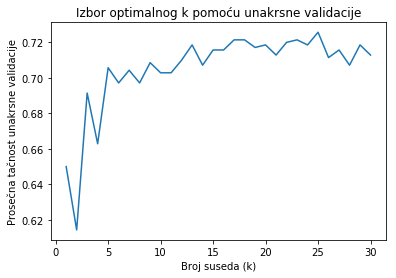

In [40]:
#Vizuelni prikaz tačnost unakrsne validacije u zavisnosti od $k$
import matplotlib.pyplot as plt
plt.figure()
plt.plot(k_vrednosti, UnakrsnaValidacija_tacnosti)
plt.xlabel("Broj suseda (k)")
plt.ylabel("Prosečna tačnost unakrsne validacije")
plt.title("Izbor optimalnog k pomoću unakrsne validacije")
plt.show()

Sada ćemo u listi vrednosti tačnosti dobijenih unakrsnom validacijom proveriti koju tačnost model postiže za $k=5$.  
Pošto indeksiranje u nizu počinje od nule, vrednost za $k=5$ nalazi se na poziciji sa indeksom 4 u listi `UnakrsnaValidacija_tacnosti`.


In [44]:
UnakrsnaValidacija_tacnosti[4]

0.7057142857142857

Na osnovu primene unakrsne validacije, zaključeno je da se najveća tačnost modela postiže za vrednost parametra $k=25$, pri čemu maksimalna ostvarena tačnost iznosi približno 0.7257142857142858. Na grafikonu se ova vrednost ističe kao lokalni maksimum.

Iako optimalna vrednost parametra odgovara $k=25$, za vrednost $k=5$ model postiže tačnost nešto veću od 0.7, što se takođe može smatrati zadovoljavajućim rezultatom u kontekstu analize performansi modela. Izbor između ovih vrednosti zavisi od kompromisa između složenosti modela i postignute tačnosti.
